IMPORTACIÓN DE LIBRERÍAS 

----

In [ ]:
# Manejo de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

# Preprocesamiento (¡VITAL en no supervisado!)
from sklearn.preprocessing import StandardScaler

# Modelos de Clustering y PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Métricas y Dendrograma
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [137]:
df = pd.read_csv('datasets/Social_media_impact_on_life.csv')

print(f"Este dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")


Este dataset tiene 1705 filas y 11 columnas.


In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 146.7 KB


In [139]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


In [140]:
df.isnull().sum() 

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [141]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


fijarse en los duplicados !!

In [142]:
df.duplicated().sum()

np.int64(0)

----- 
VISUAL EDA

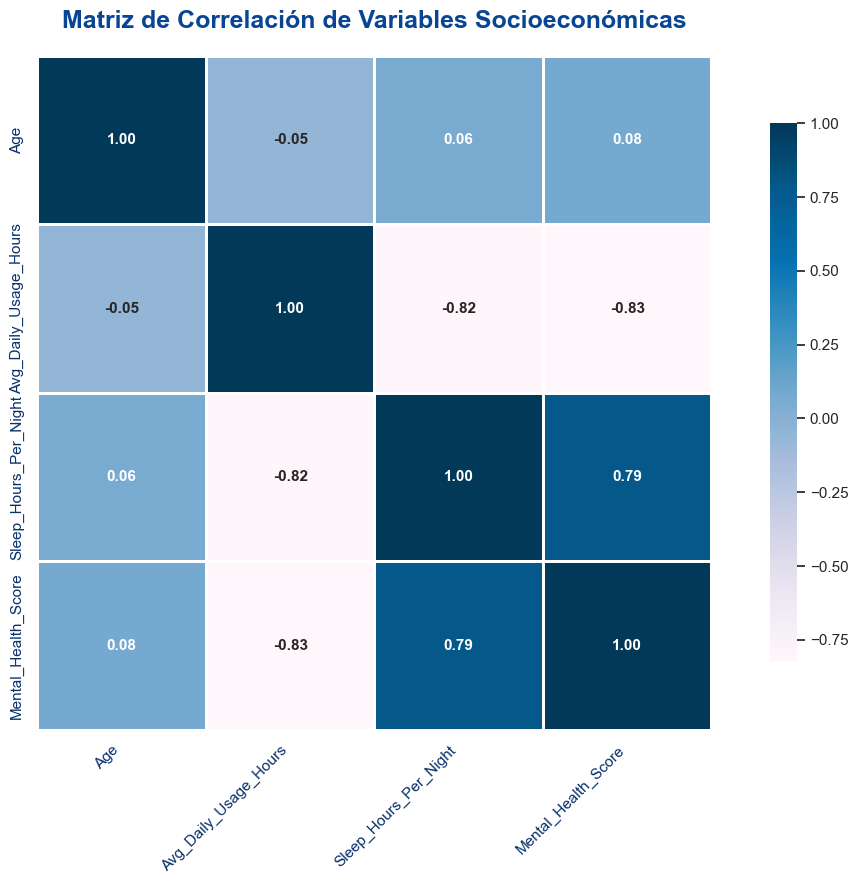

In [143]:
sns.set_theme(style="white")
# recordar que 'Student_ID' es un identificador único, no una variable numérica relevante para el análisis de correlación
# solo seleccionamos las columnas numéricas relevantes para la matriz de correlación
numeric_df = df.select_dtypes(include=np.number).drop('Student_ID', axis=1, errors='ignore')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix, 
    annot=True,                              
    cmap='PuBu',                            
    fmt=".2f",                               
    linewidths=1,                        
    linecolor='white',                    
    cbar_kws={"shrink": .8},                 
    square=True,                            
    annot_kws={"size": 11, "weight": "bold"} 
)

plt.title('Matriz de Correlación de Variables Socioeconómicas', 
        fontsize=18, fontweight='bold', color='#084594', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11, color='#08306b')
plt.yticks(fontsize=11, color='#08306b')

plt.tight_layout()
plt.show()

tenemos correlaciones fuertes se podria aplicar pca...

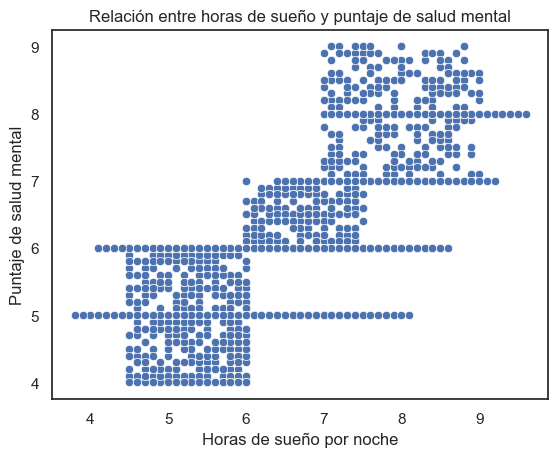

In [144]:
sns.scatterplot(data=df, x="Sleep_Hours_Per_Night", y="Mental_Health_Score")
plt.title("Relación entre horas de sueño y puntaje de salud mental")
plt.xlabel("Horas de sueño por noche")
plt.ylabel("Puntaje de salud mental")
plt.show()          

fijarse en las columnas por ejemplo este caso el student_id no es algo que necesitamos solo para saber que persona es entoces 

In [158]:
# dropear las columas que no aportan información relevante para el clustering, como 'Student_ID' que es un identificador único
df_limpio = df.drop('Student_ID', axis=1, errors='ignore')  

como tenemos columnas categoricas tendremos que transformalas ya que la ia solo entiende NUMEROS 

In [159]:
X = pd.get_dummies(df_limpio, drop_first=True)


ahora escalamos ya que se basa en distancias euclideas

In [160]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

pasamos a seleccionar el valor de k de numeros de clusteres a través de el metodo codo que se basa en la funcion de inercia y luego el silhoutte score 

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

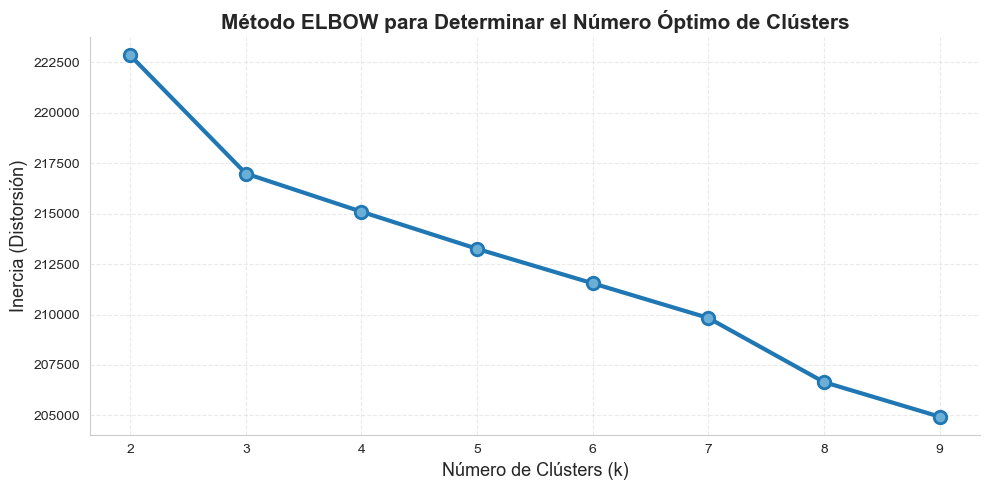

In [161]:

sns.set_style("whitegrid")
distortions = []
K_range = range(2, 10)

for k in K_range:
    kmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeanModel.fit(df_scaled)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    K_range,
    distortions,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Inercia (Distorsión)", fontsize=13)
plt.title("Método ELBOW para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

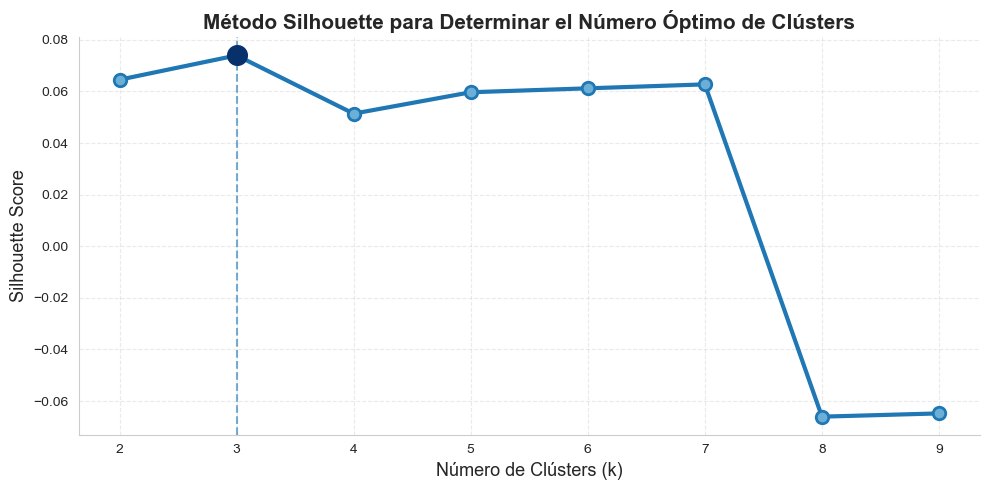

In [162]:
sns.set_style("whitegrid")

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(df_scaled)
    score = silhouette_score(df_scaled, kmeans.labels_, metric='euclidean')
    scores.append(score)

scores = np.array(scores)

best_k = list(K_range)[scores.argmax()]
best_score = scores.max()

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    list(K_range),
    scores,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

#esto es para resaltar el mejor k
plt.scatter(best_k, best_score, s=200, color="#08306b", zorder=3)
plt.axvline(best_k, linestyle="--", alpha=0.6)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Método Silhouette para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

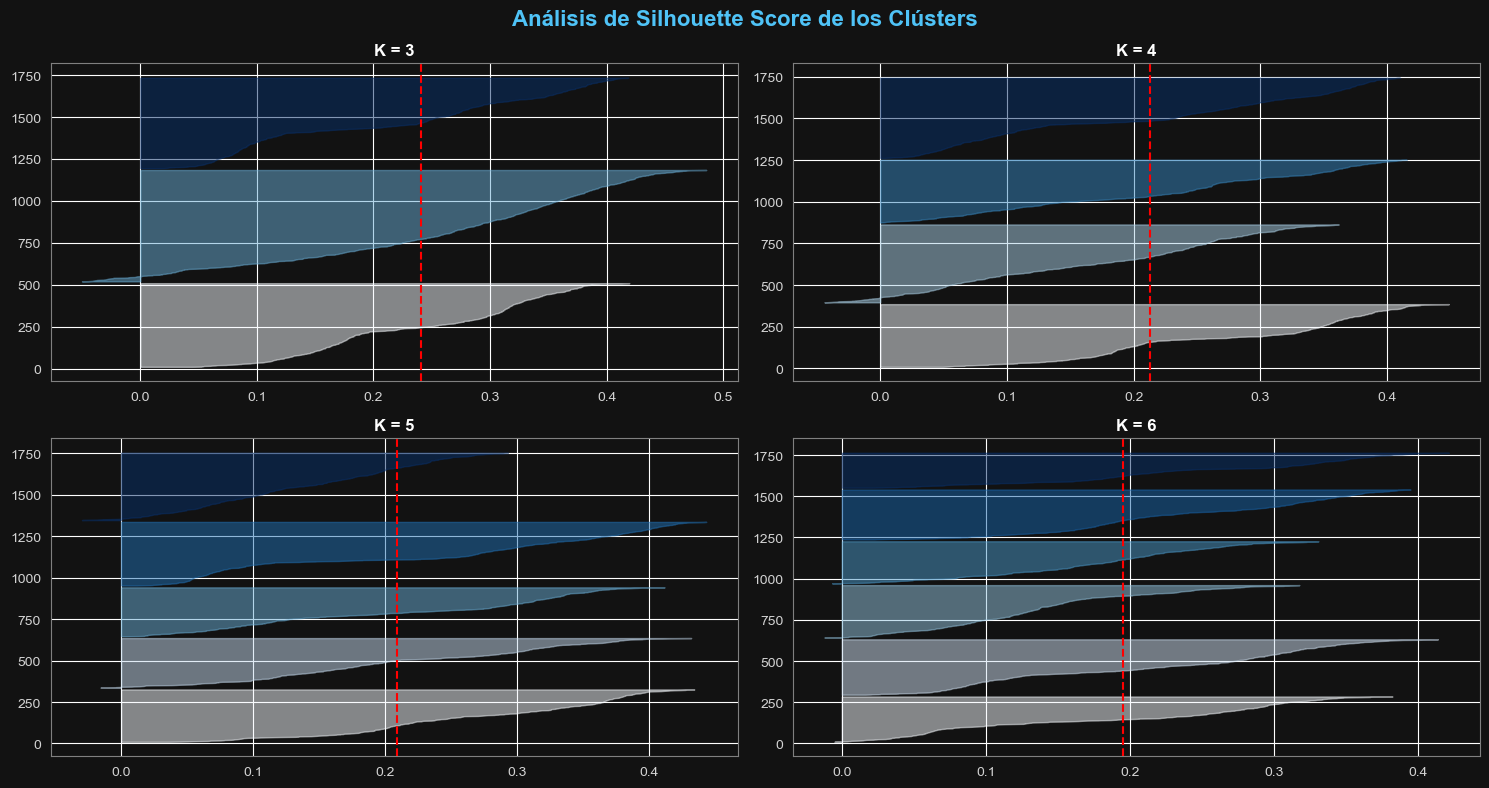

In [163]:


plt.style.use('dark_background')

fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig.patch.set_facecolor('#121212') 

k_values = [3, 4, 5, 6]

for i, k in enumerate(k_values):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    
    fila = i // 2
    columna = i % 2
    
    ax[fila][columna].set_facecolor('#121212')
    
    # Al usar 'Blues' sobre fondo negro, los azules resaltarán muchísimo más
    visualizer = SilhouetteVisualizer(km, colors='Blues', ax=ax[fila][columna])
    
    visualizer.fit(X)
    
    ax[fila][columna].set_title(f"K = {k}", color="white", fontsize=12, weight="bold")
    
    ax[fila][columna].tick_params(colors='lightgray')
    for spine in ax[fila][columna].spines.values():
        spine.set_color('gray')

fig.suptitle("Análisis de Silhouette Score de los Clústers", color="#4fc3f7", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

plt.style.use('default')

duda aqui en el visualizer s ele pasa el df esclado o no porque si se lo pasa escaldo muestra cosas raras. !!!!

segun las graficas vistas creo que lo mas optimo est omar elññ k 3 ya que esta mas o menos del mismo grosor los clusters 

In [164]:
k = 3

In [167]:
kmeans = KMeans(n_clusters=k, n_init='auto', init='k-means++', random_state=30)
# random_state si no se fija, cada vez q se ejecuta el algoritmo los centroides iniciales caen en != lugares 
# como k means es sensible a la posicion inicial y el agrupamiento final podria cambiar ligeramente en la ejecucion
# entonces pasarle el num le obligas a que use esa secuencia 


In [168]:
kmeans_pred = kmeans.fit_predict(df_scaled)                   

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


In [169]:
df['Cluster'] = kmeans_pred

In [170]:
print(df['Cluster'].value_counts())

Cluster
1    1677
2      27
0       1
Name: count, dtype: int64


In [171]:
print("\n--- PERFIL MEDIO DE CADA GRUPO ---")
resultados = df.groupby('Cluster').mean(numeric_only=True)[['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']]
display(resultados)


--- PERFIL MEDIO DE CADA GRUPO ---


,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Cluster,,,,
0,20.000000,4.600000,5.900000,6.000000
1,20.840787,5.128861,6.573405,6.191294
2,21.333333,3.555556,8.196296,7.703704


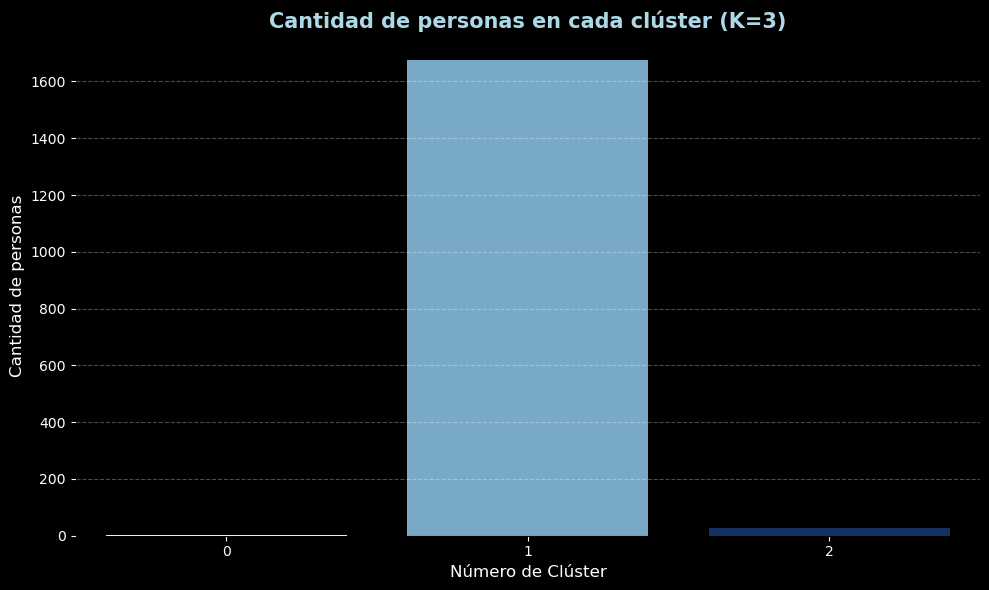

In [183]:
plt.figure(figsize=(10, 6), facecolor='black')

ax = sns.countplot(
    x='Cluster',
    data=df,
    hue='Cluster',
    palette='Blues',
    legend=False
)

ax.set_facecolor('black')

plt.title('Cantidad de personas en cada clúster (K=3)', fontsize=15, weight='bold', color='lightblue')
plt.xlabel('Número de Clúster', fontsize=12, color='white')
plt.ylabel('Cantidad de personas', fontsize=12, color='white')

ax.tick_params(colors='white')

plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')

plt.tight_layout()
plt.show()

In [177]:
print(silhouette_score(df_scaled, kmeans_pred))

0.022455554234744327


USANDO PCA AHORA

----

In [178]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(df_scaled)


In [179]:
kmeans_pca = KMeans(n_clusters=3, n_init='auto', random_state=42)
kmeans_pca.fit(X_pca)

c:\Users\nicki\miniconda3\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [181]:
df['cluster-pca'] = kmeans_pca.labels_

In [180]:
print(silhouette_score(X_pca, kmeans_pca.labels_))

0.1044353806726662


In [184]:
varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza por componente: {varianza_explicada}")
print(f"Varianza total conservada: {sum(varianza_explicada)*100:.2f}%")

Varianza por componente: [0.03170609 0.02022838 0.01799273 0.01557241 0.01483901 0.01428354
 0.01315366 0.01201771 0.01117522 0.01027557 0.01013448 0.00992119
 0.00941949 0.00931742 0.00899429 0.00878491 0.00832347 0.00813828
 0.00797101 0.00794455 0.00787859 0.00784653 0.00782407 0.00777076
 0.00774196 0.00772036 0.00768684 0.00768382 0.00767585 0.00766863
 0.00766268 0.00765448 0.00764481 0.00764082 0.00763492 0.00762961
 0.00762708 0.00761639 0.00761157 0.00760602 0.00760051 0.00759998
 0.00759532 0.00758424 0.00758335 0.00758135 0.00758114 0.00758026
 0.0075802  0.0075802  0.0075802  0.0075802  0.0075802  0.0075802
 0.0075802  0.0075802  0.0075802  0.0075802  0.0075802  0.0075802
 0.0075802  0.0075802  0.0075802  0.0075802  0.0075802  0.0075802
 0.0075802  0.0075802  0.0075802  0.0075802  0.0075802  0.0075802
 0.0075802  0.0075802  0.0075802  0.0075802  0.0075802  0.0075802
 0.0075802  0.0075802  0.0075802  0.0075802  0.0075802  0.0075802
 0.0075802  0.0075802  0.0075802  0.0075802

ha mejorado al hacer PCA mejorando la calidad de los grupos 

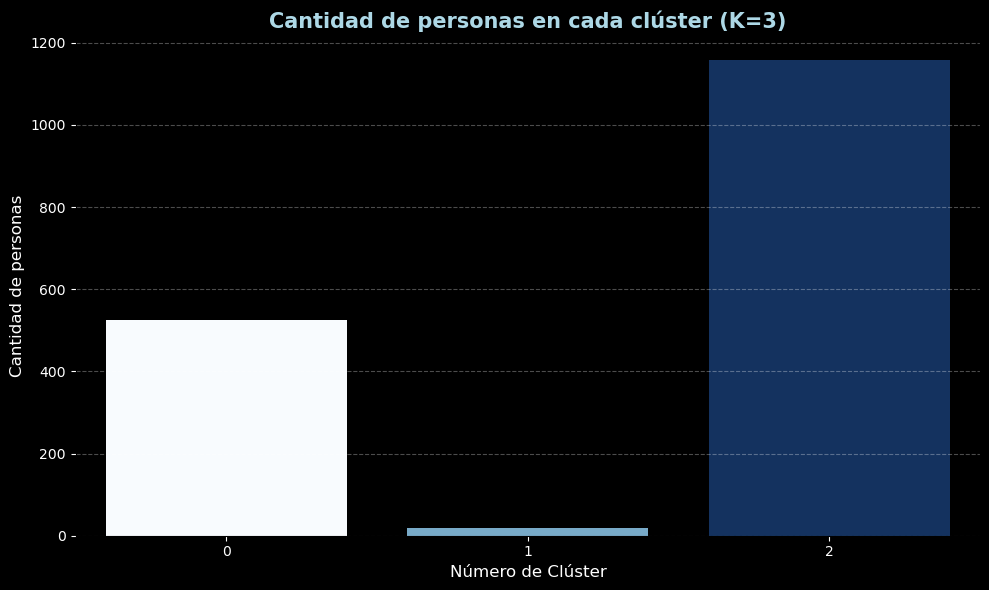

In [182]:
plt.figure(figsize=(10, 6), facecolor='black')

ax = sns.countplot(
    x='cluster-pca',
    data=df,
    hue='cluster-pca',
    palette='Blues',
    legend=False
)

ax.set_facecolor('black')

plt.title('Cantidad de personas en cada clúster (K=3)', fontsize=15, weight='bold', color='lightblue')
plt.xlabel('Número de Clúster', fontsize=12, color='white')
plt.ylabel('Cantidad de personas', fontsize=12, color='white')

ax.tick_params(colors='white')

plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')

plt.tight_layout()
plt.show()

-----

CLUSTERING JERARQUICO

----

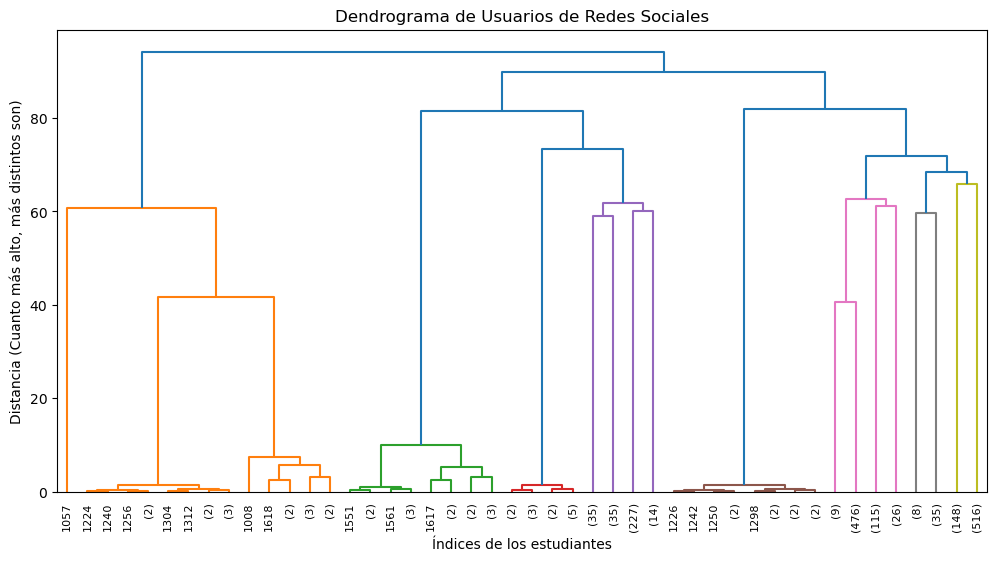

In [185]:

plt.figure(figsize=(12, 6))
plt.title("Dendrograma de Usuarios de Redes Sociales")
plt.xlabel("Índices de los estudiantes")
plt.ylabel("Distancia (Cuanto más alto, más distintos son)")

# 'linkage' es el motor que calcula las distancias para unir las ramas
# 'ward' es el método más clásico: minimiza la varianza dentro del grupo
matriz_distancias = linkage(X_scaled, method='ward')

# Dibujamos el árbol (solo mostramos las últimas ramas para que no se sature)
dendrogram(matriz_distancias, truncate_mode='level', p=5)
plt.show()


In [186]:

jerarquico = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
etiquetas_jerarquico = jerarquico.fit_predict(X_scaled)


In [187]:
score_jerarquico = silhouette_score(X_scaled, etiquetas_jerarquico)

df['Cluster_Jerarquico'] = etiquetas_jerarquico

print(f"Nota Silhouette del modelo JERÁRQUICO: {score_jerarquico:.3f}")


Nota Silhouette del modelo JERÁRQUICO: 0.106


-----

USANDO PCA COMO VISUALIZACION

-----


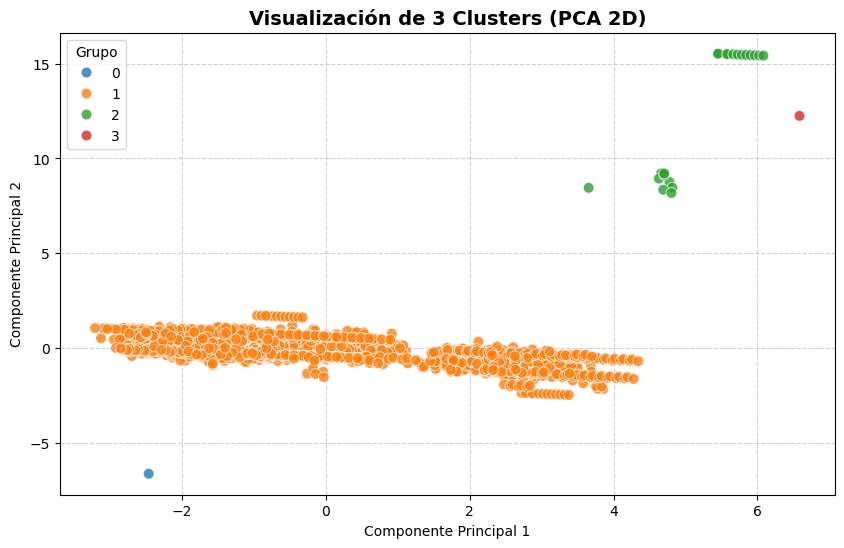


--- PERFIL MEDIO DE CADA GRUPO ---


,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
cluster-kmeans,,,,
0,20.000000,4.600000,5.900000,6.000000
1,20.861474,5.122889,6.582164,6.192509
2,19.714286,3.695238,7.938095,7.952381
3,23.000000,2.800000,7.000000,8.000000


In [193]:
# ==============================================================================
# 6. VISUALIZACIÓN EN 2D (EL MAPA)
# ==============================================================================
# Aplastamos a 2 dimensiones exactas solo para poder dibujar
pca_visual = PCA(n_components=2, random_state=42)
X_2D = pca_visual.fit_transform(X_scaled)

df['PCA_X'] = X_2D[:, 0]
df['PCA_Y'] = X_2D[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA_X', y='PCA_Y', hue='cluster-kmeans', palette='tab10', data=df, s=60, alpha=0.8)
plt.title(f"Visualización de {k} Clusters (PCA 2D)", fontsize=14, fontweight='bold')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Grupo")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==============================================================================
# 7. INTERPRETACIÓN DE LOS RESULTADOS (LA TABLA FINAL)
# ==============================================================================
print("\n--- PERFIL MEDIO DE CADA GRUPO ---")
# Filtramos la tabla final solo con las columnas que pusiste en la configuración
resultados = df.groupby('cluster-kmeans').mean(numeric_only=True)[['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']]
display(resultados)